# Glycemic Index and Dietary Impact Analysis

**How do food group, processing method and carbohydrate type relate to a food's glycemic index (GI) and glycemic load (GL)?**

This notebook analyses 2,091 foods from the 2021 international GI tables (Atkinson et al., *American Journal of Clinical Nutrition*), linked where possible to carbohydrate composition from USDA FoodData Central (SR Legacy, 2018).

| Question | Test | Answer in short |
|---|---|---|
| H1. Does GI differ between food groups? | Kruskal–Wallis, Dunn post-hoc (Holm) | Yes, strongly. Group explains about a third of the rank variance in GI. |
| H2. Does processing change GI *within the same food*? | Mann–Whitney contrasts (Holm); Friedman and Wilcoxon on matched sweet potato cultivars | Dry heat raises sweet potato GI by about 40 points. Other contrasts point the expected way but are underpowered. |
| H3. Does the carbohydrate mix (starch, sugar, fiber) predict GI? | Spearman; OLS with robust and clustered errors | Starch-rich foods have higher GI; more fiber or sugar goes with lower GI. |
| H4. Does the *type* of sugar matter? | Spearman on glucose-yielding share | Yes. Carbohydrate that digests to glucose raises GI; fructose and galactose lower it. |
| GL. What drives glycemic load? | Log-variance decomposition | Carbohydrate per serving matters slightly more than GI itself. |

Background: GI ranks how much 50 g (sometimes 25 g) of available carbohydrate from a food raises blood glucose over two hours, relative to glucose or white bread (= 100). GL scales GI by the carbohydrate in a typical serving: **GL = GI × available carbohydrate per serving (g) / 100**. The usual GI bands are low ≤ 55, medium 56–69 and high ≥ 70.

## 1. Data and pipeline

Every step is reproducible from the files in `data/raw/`:

1. `src/parse_gi_table.py` extracts Supplemental Table 1 from the published PDF, using text coordinates and font styles to rebuild rows, food groups and subgroups. Table 1 holds only values measured to the ISO 26642:2010 standard; the weaker Table 2 values are left out.
2. `src/label_processing.py` assigns a processing method (boiled, baked, instant, …) from each food's description, and falls back to the section heading only when it names exactly one method.
3. `src/match_usda.py` links foods to USDA SR Legacy entries through strict name matching, restricted to plausible USDA categories and agreeing on variety, form and cooking state. Borderline matches are left out.

Starch is taken from USDA where measured. Otherwise it is estimated as carbohydrate − sugars − fiber, which tracks measured starch closely (r = 0.96 where both exist). Composition is expressed as **shares of total carbohydrate**, so dry and cooked forms of a food stay comparable.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

sys.path.insert(0, str(Path.cwd().parent / "src"))
import analysis as A

FIGURES = Path.cwd().parent / "figures"
FIGURES.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.precision", 3)
pd.set_option("display.max_colwidth", 70)

foods = A.load_foods()
matches = A.load_matches()
profiles = A.carbohydrate_profiles(matches)

print(f"{len(foods):,} foods, {foods['reference_id'].nunique()} source studies, {foods['country'].nunique()} countries")
print(f"{foods['processing'].ne('').sum():,} foods with a processing label")
print(f"{len(matches):,} foods matched to {len(profiles)} distinct USDA foods "
      f"({(profiles['starch_source'] == 'measured').sum()} with measured starch)")

2,091 foods, 150 source studies, 69 countries
580 foods with a processing label
313 foods matched to 94 distinct USDA foods (36 with measured starch)


## 2. Overview

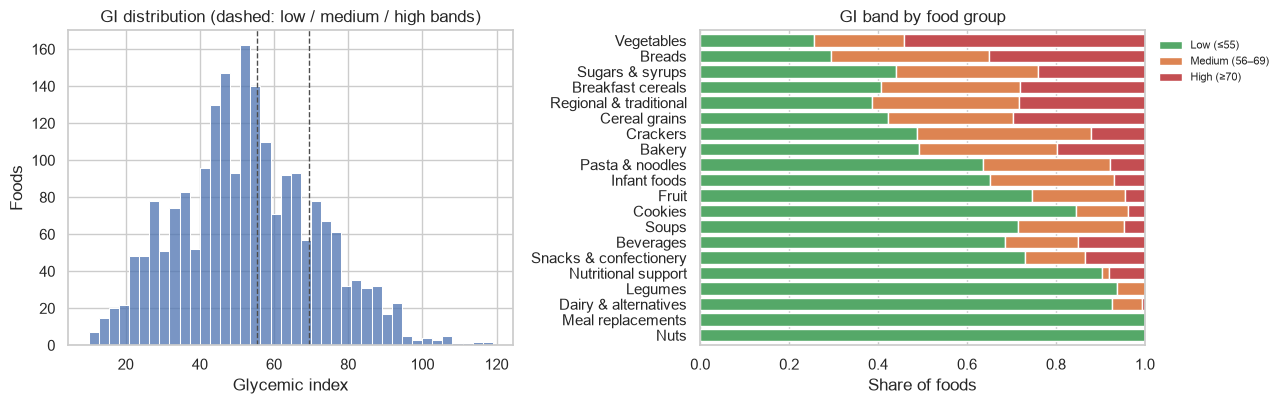

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.histplot(foods["gi"], bins=40, ax=axes[0], color="#4C72B0")
for edge in (55.5, 69.5):
    axes[0].axvline(edge, color="0.3", ls="--", lw=1)
axes[0].set(xlabel="Glycemic index", ylabel="Foods", title="GI distribution (dashed: low / medium / high bands)")

band_order = [label for *_, label in A.GI_BANDS]
order = foods.groupby("group")["gi"].median().sort_values().index
shares = pd.crosstab(foods["group"], foods["gi_band"], normalize="index").reindex(order)[band_order]
shares.plot.barh(stacked=True, ax=axes[1], color=["#55A868", "#DD8452", "#C44E52"], width=0.8)
axes[1].set(xlabel="Share of foods", ylabel="", title="GI band by food group")
axes[1].legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / "gi_overview.png", dpi=150, bbox_inches="tight")

In [3]:
print(foods["gi"].describe().round(1).to_string())
print(foods["gi_band"].value_counts(normalize=True).reindex(band_order).round(3).to_string())

count    2091.0
mean       53.0
std        18.7
min        10.0
25%        40.0
50%        52.0
75%        65.0
max       119.0
gi_band
Low (≤55)         0.588
Medium (56–69)    0.220
High (≥70)        0.192


The median food has a GI of 52; 59% of foods fall in the low band and 19% in the high band. The table is far from a random sample of the food supply, though: about a third of the entries are Australian, and staples such as bread, rice and potato were studied over and over. The tests below compare foods as they appear in the published literature.

## 3. H1: GI differs between food groups

GI is bounded, skewed within some groups, and group variances differ, so a rank-based test fits better than ANOVA.

- **H₀:** GI has the same distribution in all 20 food groups.
- **Test:** Kruskal–Wallis, with ε² as effect size, then Dunn's pairwise test with Holm correction across all 190 pairs.

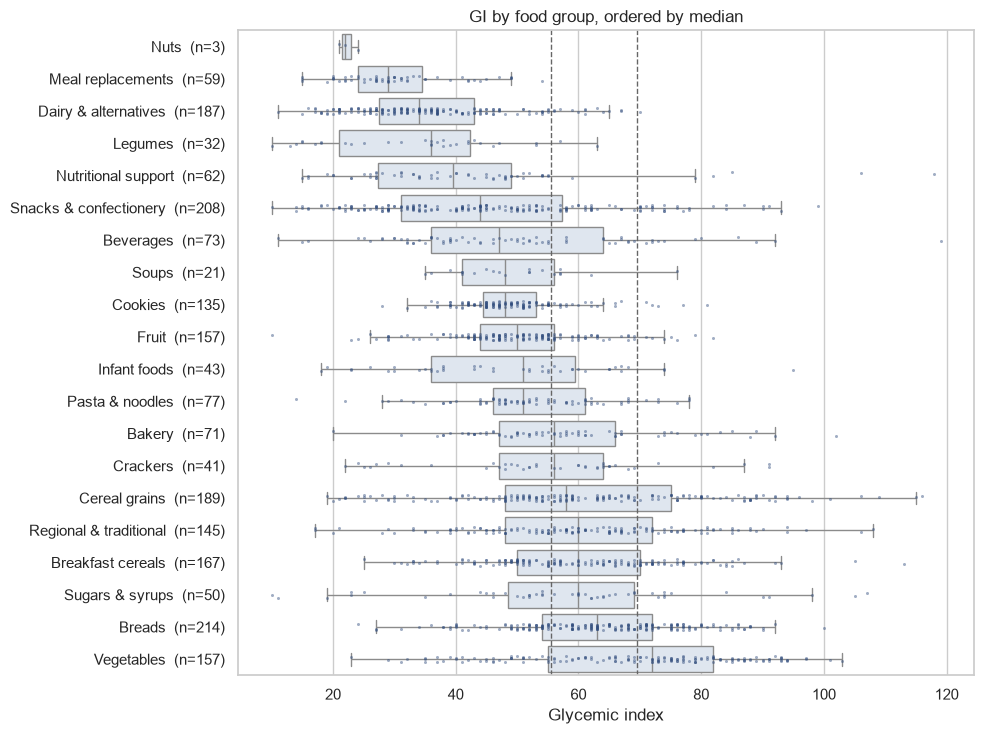

In [4]:
order = foods.groupby("group")["gi"].median().sort_values().index
fig, ax = plt.subplots(figsize=(10, 7.5))
sns.boxplot(data=foods, y="group", x="gi", order=order, color="#DCE6F2", fliersize=0, ax=ax)
sns.stripplot(data=foods, y="group", x="gi", order=order, size=2.2, alpha=0.45, color="#2F4B7C", ax=ax)
for edge in (55.5, 69.5):
    ax.axvline(edge, color="0.4", ls="--", lw=1)
counts = foods["group"].value_counts()
ax.set_yticks(range(len(order)), [f"{g}  (n={counts[g]})" for g in order])
ax.set(xlabel="Glycemic index", ylabel="", title="GI by food group, ordered by median")
fig.tight_layout()
fig.savefig(FIGURES / "gi_by_group.png", dpi=150, bbox_inches="tight")

In [5]:
samples = [g["gi"].to_numpy() for _, g in foods.groupby("group")]
kw = stats.kruskal(*samples)
eps2 = A.epsilon_squared(kw.statistic, len(foods))
print(f"Kruskal–Wallis H = {kw.statistic:.1f}, df = {len(samples) - 1}, p = {kw.pvalue:.1e}, ε² = {eps2:.2f}")

# Sensitivity: one value per study and food group, so heavily studied products do not dominate.
per_study = foods.groupby(["reference_id", "group"], as_index=False)["gi"].median()
kw_study = stats.kruskal(*[g["gi"] for _, g in per_study.groupby("group")])
print(f"One median per study × group (n = {len(per_study)}): H = {kw_study.statistic:.1f}, p = {kw_study.pvalue:.1e}, "
      f"ε² = {A.epsilon_squared(kw_study.statistic, len(per_study)):.2f}")

Kruskal–Wallis H = 659.5, df = 19, p = 1.3e-127, ε² = 0.32
One median per study × group (n = 336): H = 100.9, p = 3.6e-13, ε² = 0.30


86 of 190 group pairs differ after Holm correction


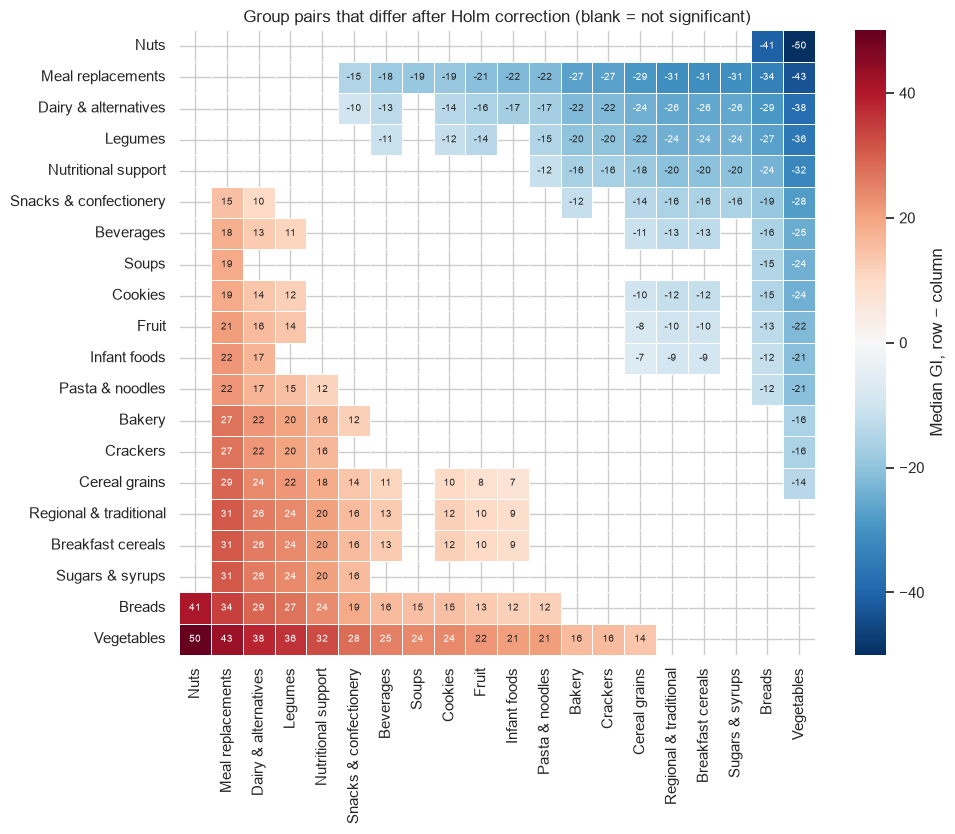

In [6]:
dunn = A.dunn_test(foods, "gi", "group")
medians = foods.groupby("group")["gi"].median()
print(f"{(dunn['p_holm'] < 0.05).sum()} of {len(dunn)} group pairs differ after Holm correction")

diff = pd.DataFrame(np.nan, index=order, columns=order)
for row in dunn.itertuples():
    if row.p_holm < 0.05:
        diff.loc[row.group_a, row.group_b] = medians[row.group_a] - medians[row.group_b]
        diff.loc[row.group_b, row.group_a] = medians[row.group_b] - medians[row.group_a]

fig, ax = plt.subplots(figsize=(10, 8.5))
sns.heatmap(diff, cmap="RdBu_r", center=0, annot=True, fmt=".0f", annot_kws={"size": 7},
            cbar_kws={"label": "Median GI, row − column"}, linewidths=0.4, linecolor="white", ax=ax)
ax.set(xlabel="", ylabel="", title="Group pairs that differ after Holm correction (blank = not significant)")
fig.tight_layout()
fig.savefig(FIGURES / "dunn_heatmap.png", dpi=150, bbox_inches="tight")

**Result.** The groups differ strongly (p ≈ 10⁻¹²⁷). Group membership explains roughly a third of the rank variance in GI, a large effect. The result holds when each study contributes only one value per group.

The ordering makes physiological sense:

- **Lowest:** nuts, meal replacements, dairy and legumes, with median GI in the 20s–30s. These are foods that are high in protein, fat or fiber, or whose sugar is lactose.
- **Highest:** vegetables, breads, breakfast cereals and cereal grains. Vegetables top the table because the vegetables in GI tables are mostly starchy ones: potato, sweet potato, cassava and pumpkin. Leafy vegetables have too little carbohydrate to be tested.

Many neighbouring groups do *not* differ significantly (the blanks in the heatmap). The big contrast is between protein, fat and lactose foods on one side and starch staples on the other.

## 4. H2: Processing changes GI within the same food

Comparing processing methods across the whole table is confounded. "Baked" foods are mostly potatoes and "canned" foods are mostly legumes, so a raw comparison mixes up the food with its preparation. The comparisons here are therefore made **within one commodity**, against boiling as the reference:

| Food | Group | Methods compared with boiled |
|---|---|---|
| Potato | Vegetables | microwaved, mashed, baked, instant |
| Sweet potato | Vegetables | fried, roasted, baked |
| Rice | Cereal grains | parboiled, instant, microwaved |
| Oats | Breakfast cereals | instant (boiled = porridge from rolled or steel-cut oats) |

- **H₀:** within each food, GI does not differ between the method and boiling.
- **Test:** Mann–Whitney U for each contrast, with Holm correction across all 11. Effect sizes are the median difference (with a 95% bootstrap interval) and Cliff's δ, the probability a food prepared by that method has a higher GI than a boiled one minus the reverse probability.

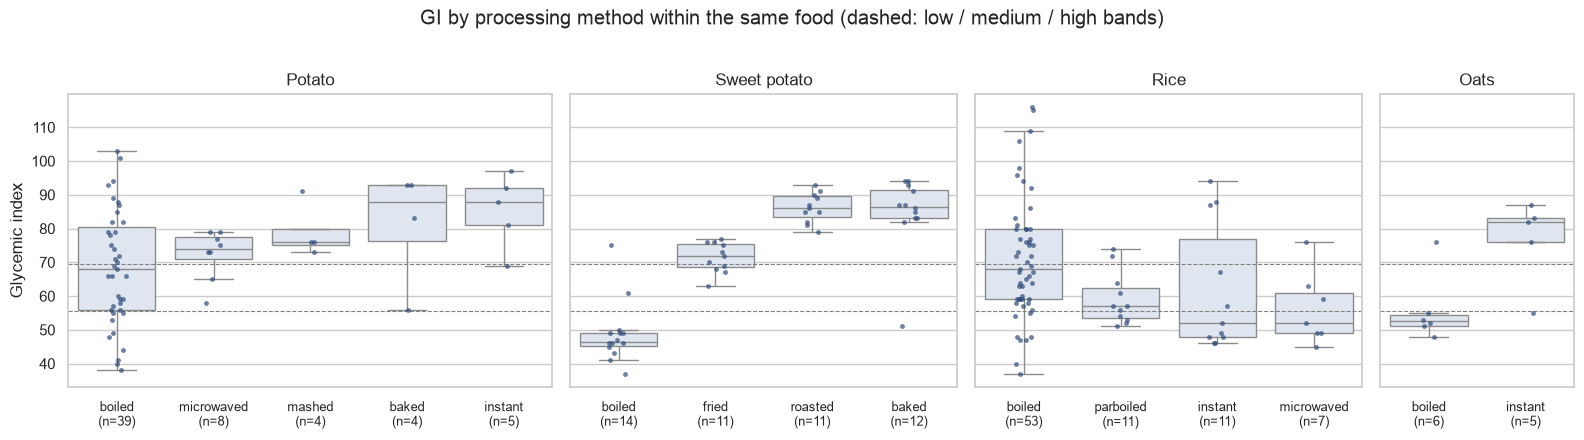

In [7]:
comparison = A.comparison_foods(foods)
fig, axes = plt.subplots(1, 4, figsize=(16, 4.3), sharey=True, gridspec_kw={"width_ratios": [5, 4, 4, 2]})
for ax, (commodity, (*_, methods)) in zip(axes, A.COMPARISONS.items()):
    subset = comparison[comparison["commodity"] == commodity]
    sns.boxplot(data=subset, x="processing", y="gi", order=methods, color="#DCE6F2", fliersize=0, ax=ax)
    sns.stripplot(data=subset, x="processing", y="gi", order=methods, color="#2F4B7C", size=3.5, alpha=0.7, ax=ax)
    n = subset["processing"].value_counts()
    ax.set_xticks(range(len(methods)), [f"{m}\n(n={n.get(m, 0)})" for m in methods], fontsize=9)
    for edge in (55.5, 69.5):
        ax.axhline(edge, color="0.5", ls="--", lw=0.8)
    ax.set(title=commodity, xlabel="", ylabel="Glycemic index" if ax is axes[0] else "")
fig.suptitle("GI by processing method within the same food (dashed: low / medium / high bands)", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES / "processing_within_food.png", dpi=150, bbox_inches="tight")

In [8]:
contrasts = A.processing_contrasts(comparison)
contrasts["95% CI"] = contrasts.apply(lambda r: f"[{r.ci_low:+.0f}, {r.ci_high:+.0f}]", axis=1)
contrasts[["food", "method", "n_method", "n_reference", "median_method", "median_reference",
           "median_difference", "95% CI", "cliffs_delta", "p", "p_holm"]].round(3)

,food,method,n_method,n_reference,median_method,median_reference,median_difference,95% CI,cliffs_delta,p,p_holm
0,Potato,microwaved,8,39,74.0,68.0,6.0,"[-4, +17]",0.179,0.436,0.483
1,Potato,mashed,4,39,76.0,68.0,8.0,"[+1, +24]",0.423,0.174,0.483
2,Potato,baked,4,39,88.0,68.0,20.0,"[-12, +33]",0.436,0.161,0.483
3,Potato,instant,5,39,88.0,68.0,20.0,"[+0, +32]",0.590,0.035,0.175
4,Sweet potato,fried,11,14,72.0,46.5,25.5,"[+20, +30]",0.903,0.000,0.001
5,Sweet potato,roasted,11,14,86.0,46.5,39.5,"[+35, +44]",1.000,0.000,0.000
6,Sweet potato,baked,12,14,86.5,46.5,40.0,"[+35, +46]",0.976,0.000,0.000
7,Rice,parboiled,11,53,57.0,68.0,-11.0,"[-19, -3]",-0.475,0.014,0.112
8,Rice,instant,11,53,52.0,68.0,-16.0,"[-25, +19]",-0.324,0.094,0.377
9,Rice,microwaved,7,53,52.0,68.0,-16.0,"[-24, -2]",-0.523,0.026,0.157


### A matched experiment: ten sweet potato cultivars cooked four ways

One study in Table 1 cooked the *same ten cultivars* by boiling, frying, baking and charcoal-roasting. Each cultivar is its own control, which removes variety as a confounder. A Friedman test checks whether the four methods differ, and Wilcoxon signed-rank tests compare each method with boiling within each cultivar.

10 cultivars with all four methods; Friedman χ² = 27.5, p = 4.5e-06
  fried    − boiled: median +26 GI (range +18 to +29), higher in 10/10 cultivars, Wilcoxon p = 0.0020
  baked    − boiled: median +42 GI (range +36 to +45), higher in 10/10 cultivars, Wilcoxon p = 0.0020
  roasted  − boiled: median +40 GI (range +35 to +44), higher in 10/10 cultivars, Wilcoxon p = 0.0020


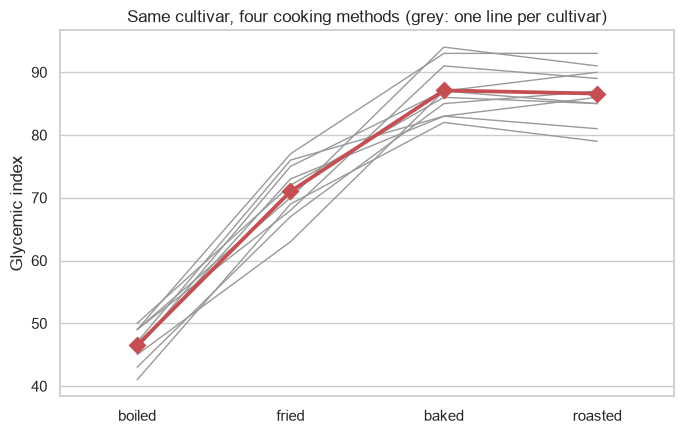

In [9]:
sweet = comparison[comparison["commodity"] == "Sweet potato"].copy()
sweet["cultivar"] = sweet["food_name"].map(A.cultivar)
paired = sweet[sweet["cultivar"] != ""].pivot_table(index="cultivar", columns="processing", values="gi")
paired = paired[["boiled", "fried", "baked", "roasted"]].dropna()

friedman = stats.friedmanchisquare(*[paired[m] for m in paired.columns])
print(f"{len(paired)} cultivars with all four methods; Friedman χ² = {friedman.statistic:.1f}, p = {friedman.pvalue:.1e}")
for method in ["fried", "baked", "roasted"]:
    w = stats.wilcoxon(paired[method], paired["boiled"])
    gap = paired[method] - paired["boiled"]
    print(f"  {method:8} − boiled: median +{gap.median():.0f} GI (range +{gap.min():.0f} to +{gap.max():.0f}), "
          f"higher in {(gap > 0).sum()}/{len(gap)} cultivars, Wilcoxon p = {w.pvalue:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
long = paired.reset_index().melt(id_vars="cultivar", var_name="method", value_name="gi")
sns.lineplot(data=long, x="method", y="gi", units="cultivar", estimator=None, color="0.6", lw=1, ax=ax)
sns.pointplot(data=long, x="method", y="gi", color="#C44E52", errorbar=None, ax=ax, markers="D")
ax.set(xlabel="", ylabel="Glycemic index", title="Same cultivar, four cooking methods (grey: one line per cultivar)")
fig.tight_layout()
fig.savefig(FIGURES / "sweet_potato_cultivars.png", dpi=150, bbox_inches="tight")

**Result.**

- **Sweet potato.** The evidence is decisive. In every one of the ten cultivars, frying, baking and roasting each gave a higher GI than boiling. Boiled sweet potato is low GI (about 47), while baked and roasted sweet potato is high GI (about 86). The usual explanation is that long dry heat converts starch into maltose and dextrins, which are absorbed fast. Boiling gelatinises starch without that breakdown, and some starch re-forms into a slower-digesting structure as it cools.
- **Potato and oats.** The direction is the expected one. Instant forms (instant mashed potato, instant oat porridge) and mashed or baked potato sit 8–30 points above boiled. After correction for 11 tests, these contrasts are not significant, because the instant, baked and mashed groups have only 4–8 foods each.
- **Rice goes the other way.** Parboiled, instant and microwave rice tend to have *lower* GI than ordinary boiled white rice. Many of the "instant" and pouch rices in the table are parboiled before packing, and parboiling hardens the starch structure. Boiled white rice also includes very high-GI glutinous and jasmine varieties.

So "processing" is not a single direction. Mechanical breakdown and dry heat raise GI, while parboiling lowers it.

## 5. H3: The carbohydrate mix predicts GI

The 313 matched foods map to **94 distinct USDA foods**. For example, 49 white breads all share the USDA entry "Bread, white wheat". Treating them as 313 independent observations would overstate the evidence. The primary analysis therefore uses one row per USDA food, with the median GI of the foods matched to it. A food-level model with errors clustered by USDA food is the sensitivity check.

Starch, sugar and fiber shares sum to one, so a regression can include only two of them. Starch is the omitted reference, which means each coefficient reads as "replacing starch with this component".

- **H₀:** the carbohydrate shares are unrelated to GI.

,component,spearman_rho,p
0,Starch,0.346,6.355e-04
1,Sugars,-0.254,1.360e-02
2,Fiber,-0.348,5.860e-04


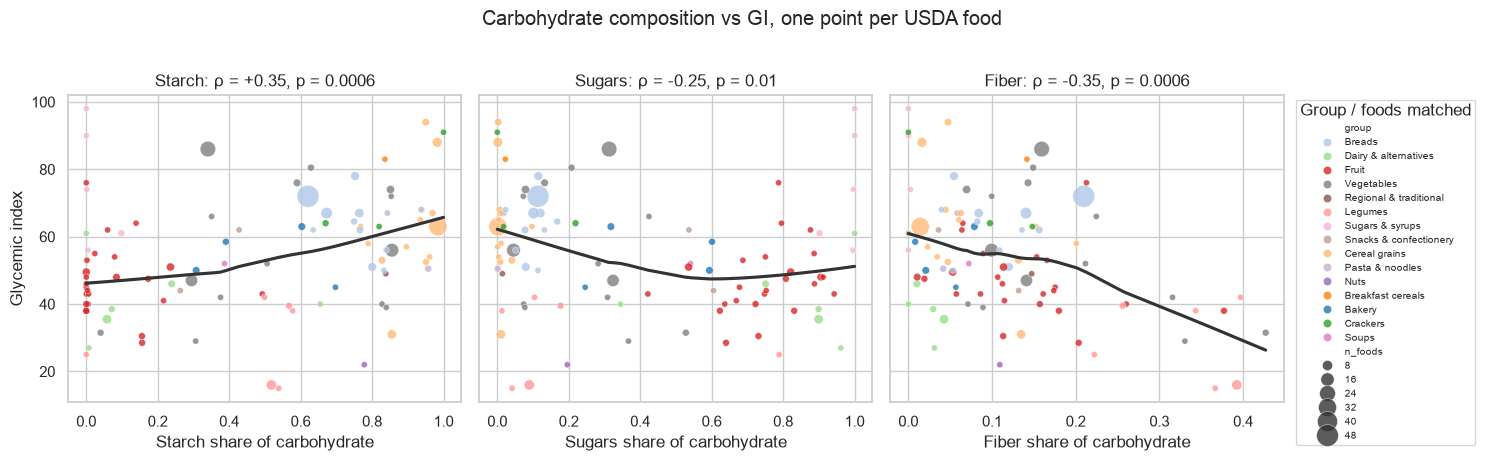

In [10]:
labels = {"starch_share": "Starch", "sugar_share": "Sugars", "fiber_share": "Fiber"}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
palette = dict(zip(sorted(profiles["group"].unique()), sns.color_palette("tab20", profiles["group"].nunique())))
rows = []
for ax, (column, label) in zip(axes, labels.items()):
    rho = stats.spearmanr(profiles[column], profiles["gi"])
    rows.append({"component": label, "spearman_rho": rho.statistic, "p": rho.pvalue})
    sns.scatterplot(data=profiles, x=column, y="gi", hue="group", size="n_foods", sizes=(20, 250),
                    palette=palette, alpha=0.8, ax=ax, legend=(ax is axes[-1]))
    sns.regplot(data=profiles, x=column, y="gi", scatter=False, lowess=True, color="0.2", ax=ax)
    ax.set(xlabel=f"{label} share of carbohydrate", ylabel="Glycemic index", title=f"{label}: ρ = {rho.statistic:+.2f}, p = {rho.pvalue:.1g}")
axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, title="Group / foods matched")
fig.suptitle("Carbohydrate composition vs GI, one point per USDA food", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES / "composition_vs_gi.png", dpi=150, bbox_inches="tight")
pd.DataFrame(rows)

In [11]:
def coefficient_table(fit, name):
    ci = fit.conf_int()
    return pd.DataFrame({"model": name, "coef": fit.params, "ci_low": ci[0], "ci_high": ci[1], "p": fit.pvalues}).drop("Intercept")

profile_fit = smf.ols("gi ~ sugar_share + fiber_share", data=profiles).fit(cov_type="HC3")
measured = profiles[profiles["starch_source"] == "measured"]
measured_fit = smf.ols("gi ~ sugar_share + fiber_share", data=measured).fit(cov_type="HC3")
food_fit = smf.ols("gi ~ sugar_share + fiber_share", data=matches).fit(
    cov_type="cluster", cov_kwds={"groups": matches["fdc_id"]})

print(f"Per USDA food: n = {len(profiles)}, R² = {profile_fit.rsquared:.2f}")
print(f"Measured starch only: n = {len(measured)}, R² = {measured_fit.rsquared:.2f}")
print(f"Per GI food, clustered by USDA food: n = {len(matches)}, R² = {food_fit.rsquared:.2f}")
pd.concat([
    coefficient_table(profile_fit, "per USDA food (HC3)"),
    coefficient_table(measured_fit, "measured starch only (HC3)"),
    coefficient_table(food_fit, "per GI food (clustered)"),
])

Per USDA food: n = 94, R² = 0.26
Measured starch only: n = 36, R² = 0.29
Per GI food, clustered by USDA food: n = 313, R² = 0.16


,model,coef,ci_low,ci_high,p
sugar_share,per USDA food (HC3),-12.717,-22.178,-3.257,8.420e-03
fiber_share,per USDA food (HC3),-82.798,-113.039,-52.557,8.039e-08
sugar_share,measured starch only (HC3),-13.638,-26.513,-0.764,3.787e-02
fiber_share,measured starch only (HC3),-78.796,-134.711,-22.881,5.745e-03
sugar_share,per GI food (clustered),-22.108,-33.474,-10.742,1.376e-04
fiber_share,per GI food (clustered),-56.259,-126.005,13.488,1.139e-01


**Result.** Starch share is positively associated with GI, and fiber and sugar shares negatively. In the USDA-food model, replacing a tenth of the carbohydrate's starch with fiber goes with about 8 GI points lower; replacing it with sugars, about 1 point lower. Composition explains roughly a quarter of the variance in GI.

Two cautions:

- **The fiber effect is less certain at the food level.** The fiber coefficient keeps its sign in the food-level model, but its interval widens to include zero once errors are clustered. Most foods there are breads and rices whose fiber share barely varies, so the food-level model has little fiber contrast to work with.
- **The sugar effect hides a split.** "Sugars" is not one thing: fructose and lactose are absorbed slowly, glucose and maltose fast. The plain sugar share averages over that difference, which is what H4 tests.

These are observational associations. Composition differences come bundled with food structure, fat and protein.

## 6. H4: The type of sugar matters

USDA reports individual sugars for about half of the matched foods. From them, carbohydrate is split by what it yields after digestion:

- **Glucose-yielding:** starch, glucose and maltose in full, plus half of sucrose and half of lactose.
- **Fructose and galactose:** free fructose and galactose, plus the other half of sucrose and lactose. These have to be converted in the liver before they show up as blood glucose.

- **H₀:** the glucose-yielding share of carbohydrate is unrelated to GI.

n = 50 USDA foods with a sugar breakdown
  glucose-yielding share      ρ = +0.45, p = 0.0010
  fructose + galactose share  ρ = -0.34, p = 0.0165
  total sugar share (same foods) ρ = -0.27, p = 0.0590


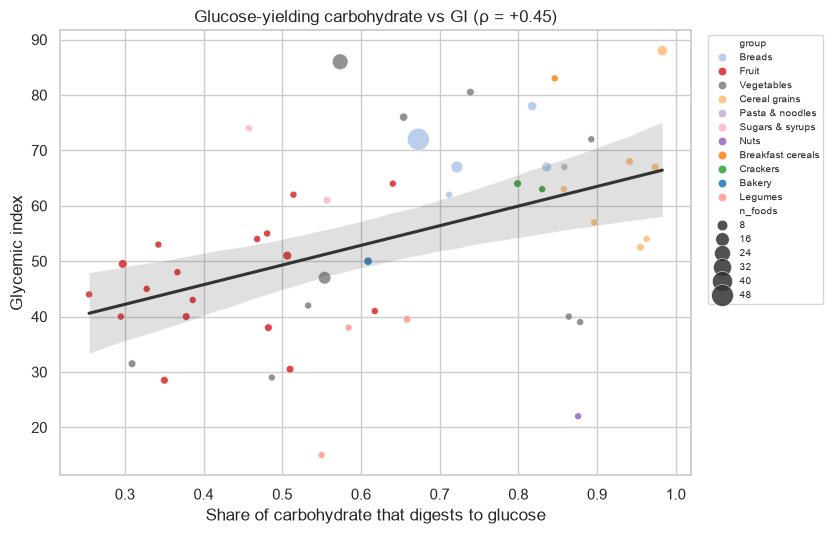

In [12]:
sugars = profiles.dropna(subset=["glucose_yield_share"]).copy()
rho = stats.spearmanr(sugars["glucose_yield_share"], sugars["gi"])
rho_fg = stats.spearmanr(sugars["fructose_galactose_share"], sugars["gi"])
rho_total = stats.spearmanr(sugars["sugar_share"], sugars["gi"])
print(f"n = {len(sugars)} USDA foods with a sugar breakdown")
print(f"  glucose-yielding share      ρ = {rho.statistic:+.2f}, p = {rho.pvalue:.4f}")
print(f"  fructose + galactose share  ρ = {rho_fg.statistic:+.2f}, p = {rho_fg.pvalue:.4f}")
print(f"  total sugar share (same foods) ρ = {rho_total.statistic:+.2f}, p = {rho_total.pvalue:.4f}")

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.scatterplot(data=sugars, x="glucose_yield_share", y="gi", hue="group", size="n_foods", sizes=(25, 250),
                palette=palette, alpha=0.85, ax=ax)
sns.regplot(data=sugars, x="glucose_yield_share", y="gi", scatter=False, color="0.2", ax=ax)
ax.set(xlabel="Share of carbohydrate that digests to glucose", ylabel="Glycemic index",
       title=f"Glucose-yielding carbohydrate vs GI (ρ = {rho.statistic:+.2f})")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
fig.tight_layout()
fig.savefig(FIGURES / "glucose_yield_vs_gi.png", dpi=150, bbox_inches="tight")

In [13]:
sweeteners = profiles[profiles["group"] == "Sugars & syrups"]
sweeteners[["usda_description", "gi", "n_foods", "sugar_share", "glucose_yield_share"]].sort_values("gi")

,usda_description,gi,n_foods,sugar_share,glucose_yield_share
32,"Syrups, corn, high-fructose",56.0,1,0.995,NaN
34,"Syrups, maple",61.0,2,0.902,0.557
31,Honey,74.0,1,0.997,0.458
21,"Syrups, corn, dark",90.0,1,1.000,NaN
33,"Syrups, malt",98.0,1,1.000,NaN


**Result.** The share of carbohydrate that digests to glucose correlates positively with GI, and the fructose-and-galactose share negatively. Both relationships are clearer than the one with total sugar.

Among these 50 foods, total sugar share is only weakly related to GI (p ≈ 0.06), so splitting sugars by type is what makes the difference.

The matched sweeteners in the table above show the same thing. All five are essentially 100% sugar, yet their GI runs from 56 to 98:

- High-fructose corn syrup (GI 56) is about half fructose, and maple syrup (GI 61) is mostly sucrose.
- Malt syrup (GI 98) is mostly maltose, which is two glucose units, and dark corn syrup (GI 90) is glucose and maltose.

USDA has no individual-sugar breakdown for three of these syrups, so they are not in the correlation above. Their ordering follows the same pattern.

**For carbohydrate and GI, the key question is how much of the carbohydrate ends up as glucose, not simply "starch versus sugar".** This analysis is exploratory: it covers only the foods with a full USDA sugar breakdown, and those skew towards fruit and sweeteners.

## 7. Glycemic load: GI is only half the story

GL multiplies GI by the carbohydrate in a typical serving, so a high-GI food eaten in small amounts can have a low GL. On the log scale the relationship is additive, **log GL = log GI + log carbohydrate per serving − log 100**, so the variance of log GL splits exactly into a GI part, a serving-carbohydrate part and their covariance.

Share of variance in log GL:
GI                          0.42
carbohydrate per serving    0.53
covariance (×2)             0.05
Spearman GL~GI ρ = 0.67, GL~serving carbohydrate ρ = 0.70


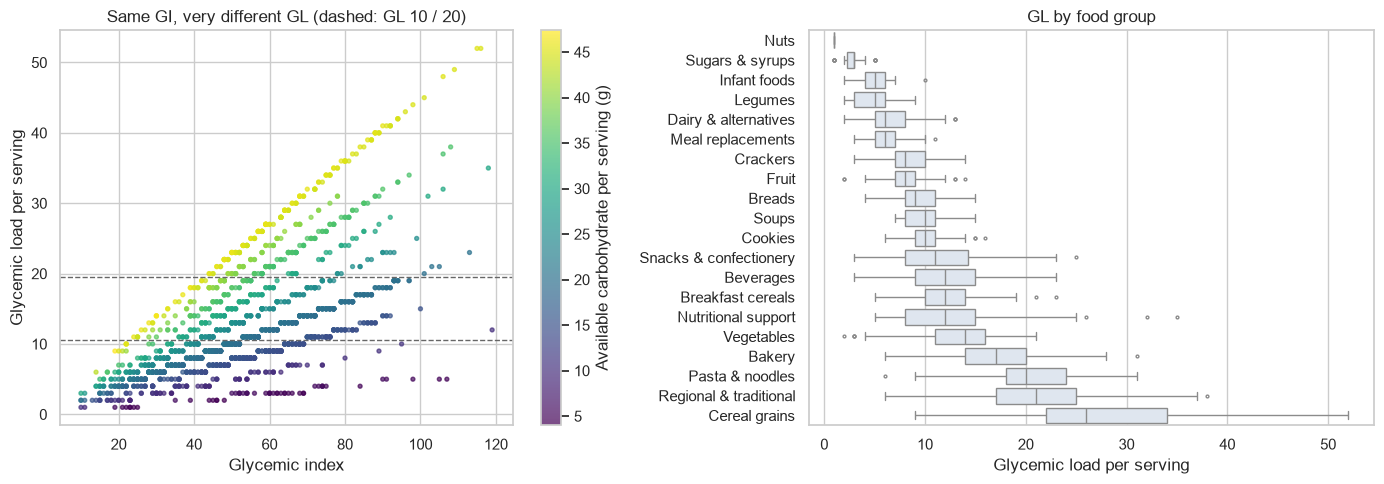

In [14]:
gl = foods.dropna(subset=["gl", "serving_carb_g"]).copy()
log_gi, log_carb, log_gl = np.log(gl["gi"]), np.log(gl["serving_carb_g"]), np.log(gl["gl"])
total = log_gl.var()
parts = pd.Series({
    "GI": log_gi.var() / total,
    "carbohydrate per serving": log_carb.var() / total,
    "covariance (×2)": 2 * np.cov(log_gi, log_carb)[0, 1] / total,
})
print("Share of variance in log GL:")
print(parts.round(2).to_string())
print(f"Spearman GL~GI ρ = {stats.spearmanr(gl['gl'], gl['gi']).statistic:.2f}, "
      f"GL~serving carbohydrate ρ = {stats.spearmanr(gl['gl'], gl['serving_carb_g']).statistic:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
points = axes[0].scatter(gl["gi"], gl["gl"], c=gl["serving_carb_g"], cmap="viridis", s=8, alpha=0.7)
fig.colorbar(points, ax=axes[0], label="Available carbohydrate per serving (g)")
axes[0].axhline(10.5, color="0.4", ls="--", lw=1)
axes[0].axhline(19.5, color="0.4", ls="--", lw=1)
axes[0].set(xlabel="Glycemic index", ylabel="Glycemic load per serving", title="Same GI, very different GL (dashed: GL 10 / 20)")

gl_order = gl.groupby("group")["gl"].median().sort_values().index
sns.boxplot(data=gl, y="group", x="gl", order=gl_order, color="#DCE6F2", fliersize=2, ax=axes[1])
axes[1].set(xlabel="Glycemic load per serving", ylabel="", title="GL by food group")
fig.tight_layout()
fig.savefig(FIGURES / "glycemic_load.png", dpi=150, bbox_inches="tight")

In [15]:
rank = pd.DataFrame({
    "median GI": foods.groupby("group")["gi"].median(),
    "median GL": gl.groupby("group")["gl"].median(),
    "median carbohydrate per serving (g)": gl.groupby("group")["serving_carb_g"].median(),
})
rank["GI rank"] = rank["median GI"].rank(ascending=False).astype(int)
rank["GL rank"] = rank["median GL"].rank(ascending=False).astype(int)
rank.sort_values("median GL", ascending=False).round(1)

,median GI,median GL,median carbohydrate per serving (g),GI rank,GL rank
group,,,,,
Cereal grains,58.0,26.0,45.0,6,1
Regional & traditional,60.0,21.0,35.0,4,2
Pasta & noodles,51.0,20.0,39.7,9,3
Bakery,56.0,17.0,30.0,7,4
Vegetables,72.0,14.0,20.0,1,5
Beverages,47.0,12.0,25.0,14,7
Nutritional support,39.5,12.0,30.1,16,7
Breakfast cereals,60.0,12.0,20.0,4,7
Snacks & confectionery,44.0,11.0,25.0,15,9


**Result.** Carbohydrate per serving accounts for slightly more of the variation in GL than GI does. The two are nearly independent, so their covariance contributes little.

Food groups reorder when ranked by GL instead of GI:

- **Cereal grains and pasta** have medium GI, but a serving carries 40–45 g of carbohydrate, so they rank first and third by GL.
- **Breads** rank second by GI but only twelfth by GL, because a slice holds about 15 g of carbohydrate.
- **Sugars and syrups** have a high median GI but a serving of about 5 g, so their GL is among the lowest.

For diet advice, portion size matters about as much as which food is chosen.

## 8. Limitations

- **GI tables are not a random sample of foods.** Staples and Australian products dominate, and some products appear many times. The per-study sensitivity check (H1) and per-USDA-food analysis (H3, H4) reduce but do not remove this.
- **Processing labels come from text.** Many descriptions do not say how the food was prepared, so most foods are unlabeled. The within-food contrasts use only clearly described methods.
- **USDA composition is a proxy.** It describes a generic version of each food, not the exact product tested for GI, and starch is estimated rather than measured for about 60% of the matched USDA foods. The measured-starch-only model gives the same answer. Only strict matches are used, which leaves out branded and composite foods (cookies, breakfast cereals, meal replacements, infant foods).
- **Observational data.** Except for the matched sweet potato cultivars, these are associations between foods, not controlled interventions. Fat, protein, food structure and acidity also affect GI and are not modelled.
- **GI is measured with error.** Typical standard errors in Table 1 are 4–7 GI units, so differences of a few points between single foods are not meaningful.

## 9. Conclusions

1. **Food group matters a lot.** Legumes, dairy and nuts are reliably low GI; starchy vegetables, breads, breakfast cereals and refined grains are reliably high.
2. **Cooking method can move a food across the GI bands.** The same sweet potato is low GI when boiled and high GI when baked or roasted, consistently across ten cultivars. Instant and mashed forms tend to raise GI, while parboiling rice lowers it.
3. **Carbohydrate type predicts GI.** More starch means higher GI and more fiber lower GI. Among sugars, what counts is whether they digest to glucose (glucose, maltose) or not (fructose, galactose).
4. **Glycemic load depends as much on portion carbohydrate as on GI**, so ranking foods by GI alone can mislead.